# U-Net++ Training Pipeline

**Comprehensive pipeline for:**
- Training U-Net++ from scratch
- Parameter sweeps for BTrack and LapTrack
- Visualization and evaluation

---

## Configurations
- Train configurations
- Repo and save configurations

In [1]:
import os
import sys
import torch

print("="*70)
print("U-Net++ Training Pipeline")
print("="*70)

# ============================================================================
# CONFIGURATION - These override defaults in modules/config.py
# ============================================================================
CONFIG = {
    # Training parameters
    'TRAIN_SAMPLES': 3000,
    'VAL_SAMPLES': 400,
    'BATCH_SIZE': 16,
    'LEARNING_RATE': 1e-3,
    'WEIGHT_DECAY': 1e-4,
    'DROPOUT_RATE': 0.1,
    'EPOCHS': 50,
    'PATIENCE': 15,
    'SEED': 42,
    'BCE_WEIGHT': 0.5,  # Weight for BCE in combined loss

    # Repository settings
    'REPO_URL': 'https://github.com/gulierus/SU2_HR-net_U-net.git',
    'REPO_DIR': '/content/SU2_U-netPP',

    # Google Drive (for Colab)
    'USE_GDRIVE': True,
    'SAVE_DIR': '/content/drive/MyDrive/SU2_Project_UNetPP',
}


U-Net++ Training Pipeline


## Setup Environment
- Google drive connections
- Clone the repository with modules
- Define configurations

In [2]:
# Ensure we start in a known stable directory for consistent behavior across executions.
os.chdir('/content/')

print("\n[1/5] Setting up environment...")

# Mount Google Drive
is_colab = False
try:
    from google.colab import drive
    print("  Mounting Google Drive...")
    drive.mount('/content/drive')
    os.makedirs(CONFIG['SAVE_DIR'], exist_ok=True)
    print(f"  Results will be saved to: {CONFIG['SAVE_DIR']}")
    is_colab = True
except ImportError:
    print("  Not running on Colab, skipping Drive mount")
    CONFIG['USE_GDRIVE'] = False
    CONFIG['SAVE_DIR'] = './results'
    os.makedirs(CONFIG['SAVE_DIR'], exist_ok=True)

# Install dependencies
print("\n[2/5] Installing dependencies...")
# Dependency conflict: btrack==0.6.5 requires pydantic<2, while laptrack>=0.16.0 requires pydantic>=2.
# To resolve, we update btrack to a newer version (0.7.0) that supports pydantic>=2 and remove explicit pydantic constraint.
!pip install -q btrack==0.7.0 pyyaml "laptrack==0.17.0"
print("  Dependencies installed")

# Clone repository
print("\n[3/5] Setting up repository...")
repo_path = CONFIG['REPO_DIR']

if os.path.exists(repo_path):
    print(f"  Removing existing repository at {repo_path}...")
    shutil.rmtree(repo_path, ignore_errors=True)

print(f"  Cloning from {CONFIG['REPO_URL']}...")
!git clone "{CONFIG['REPO_URL']}" "{repo_path}"

# Pull LFS files (pretrained models)
print("  Pulling Git LFS files...")
!cd "{repo_path}" && git lfs install && git lfs pull

# Check if clone was successful
if not os.path.exists(repo_path) or not os.listdir(repo_path):
    raise RuntimeError(f"Failed to clone repository into {repo_path}")

# Add to path and change directory
sys.path.insert(0, repo_path)
os.chdir(repo_path)
print(f"  Working directory: {os.getcwd()}")


# Create config.yaml
print("\n[4/5] Creating configuration...")
config_content = f"""\n
TRAIN_SAMPLES: {CONFIG['TRAIN_SAMPLES']}
VAL_SAMPLES: {CONFIG['VAL_SAMPLES']}
BATCH_SIZE: {CONFIG['BATCH_SIZE']}
LEARNING_RATE: {CONFIG['LEARNING_RATE']}
WEIGHT_DECAY: {CONFIG['WEIGHT_DECAY']}
DROPOUT_RATE: {CONFIG['DROPOUT_RATE']}
EPOCHS: {CONFIG['EPOCHS']}
PATIENCE: {CONFIG['PATIENCE']}
SEED: {CONFIG['SEED']}

MIN_CELLS: 5
MAX_CELLS: 20
PATCH_SIZE: 128
SIM_CONFIG:
  na: 1.49
  wavelength: 512
  px_size: 0.07
  wiener_parameter: 0.1
  apo_cutoff: 2.0
  apo_bend: 0.9
"""
with open('config.yaml', 'w') as f:
    f.write(config_content)
print("  Configuration saved to config.yaml")

# Import modules
print("\n[5/5] Importing modules...")
from modules.training.train_UnetPlusPlus import train_unetplusplus_pipeline
from modules.data.dataset import SyntheticCCPDataset
from modules.models.UnetPlusPlus_model import UNetPlusPlus
from modules.eval.sweep import sweep_and_save_gif, sweep_laptrack_and_save_gif
from modules.utils import save_model_to_drive
from modules.config import DEVICE, MIN_CELLS, MAX_CELLS

print(f"  ✓ All modules imported")
print(f"  ✓ Device: {DEVICE}")



[1/5] Setting up environment...
  Mounting Google Drive...
Mounted at /content/drive
  Results will be saved to: /content/drive/MyDrive/SU2_Project_UNetPP

[2/5] Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 25.1 MB/s eta 0:00:00
  Dependencies installed

[3/5] Setting up repository...
  Cloning from https://github.com/gulierus/SU2_HR-net_U-net.git...
Cloning into '/content/SU2_HR-net'...
remote: Enumerating objects: 301, done.
remote: Counting objects: 100% (301/301), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 301 (delta 171), reused 289 (delta 165), pack-reused 0 (from 0)
Receiving objects: 100% (301/301), 19.52 MiB | 32.61 MiB/s, done.
Resolving deltas: 100% (171/171), done.
  Pulling Git LFS files...
Updated git hooks.
Git LFS initialized.
  Working directory: /

## Visualize Synthetic Dataset

- Check how the synthetic CCP data looks with clustering enabled
- For more info about improved generator please check documentation in the the repository. U can find link for the repository in README.md

=== Dataset Settings ===
min_n=5, max_n=20
use_clusters=True
cluster_sample_prob=0.5

Generating 8 sample images...


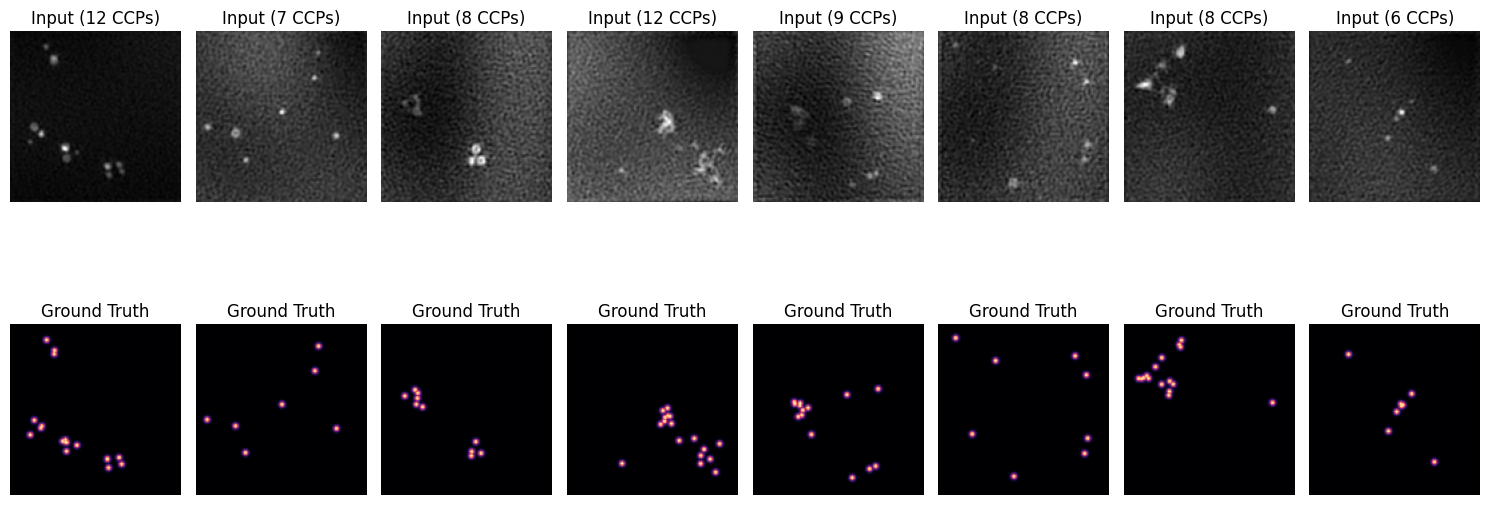

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import label

# Create generator with clusters
# Radius was randomized in this version
dataset = SyntheticCCPDataset(
    use_clusters=True,               # Enable cluster generation mode
    cluster_sample_prob=0.5,          # Probability of generating a clustered sample (0.0-1.0)
    cluster_prob=0.6,                 # Probability of forming a cluster within a sample
    cluster_size_range=(2, 9),        # Min and max CCPs per cluster
    cluster_spread=8.0                # Spatial spread of CCPs within clusters (pixels)
)


print(f"=== Dataset Settings ===")
print(f"min_n={dataset.min_n}, max_n={dataset.max_n}")
print(f"use_clusters={dataset.use_clusters}")
print(f"cluster_sample_prob={dataset.cluster_sample_prob}")
print()

# Generate samples
num_samples = 8
fig, axes = plt.subplots(2, num_samples, figsize=(15, 7))

print(f"Generating {num_samples} sample images...")
for i in range(num_samples):
    img, mask = dataset.data_sample()

    # Count CCPs
    labeled, n_cells = label(mask > 0.5)

    # Plot input
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Input ({n_cells} CCPs)')
    axes[0, i].axis('off')

    # Plot mask
    axes[1, i].imshow(mask, cmap='magma')
    axes[1, i].set_title('Ground Truth')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


## Download Validation Data

In [15]:
import requests
import zipfile

print("Downloading validation data...")

# Download certificate
chain_path = "/content/chain-harica-cross.pem"
cert_url = "https://pki.cesnet.cz/_media/certs/chain-harica-rsa-ov-crosssigned-root.pem"

try:
    r = requests.get(cert_url, timeout=10, stream=True)
    r.raise_for_status()
    with open(chain_path, 'wb') as f:
        f.write(r.content)
    print("✓ Certificate downloaded")
except Exception as e:
    print(f"⚠ Certificate download failed: {e}")
    chain_path = True

# Download validation data
zip_url = "https://su2.utia.cas.cz/files/labs/final2025/val_and_sota.zip"
extract_dir = "/content/val_data"
zip_path = "/content/temp_val.zip"

if not os.path.exists(extract_dir):
    try:
        print(f"Downloading from: {zip_url}")
        response = requests.get(zip_url, stream=True, verify=chain_path, timeout=60)
        response.raise_for_status()

        with open(zip_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("✓ ZIP downloaded")

        print("Extracting...")
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

        os.remove(zip_path)
        print(f"✓ Data extracted to: {extract_dir}")

        print("\nContents:")
        for item in os.listdir(extract_dir):
            print(f"  - {item}")

    except Exception as e:
        print(f"✗ Download failed: {e}")
else:
    print(f"✓ Validation data already exists at: {extract_dir}")


✓ Certificate downloaded
✓ ZIP downloaded
Extracting...
✓ Data extracted to: /content/val_data

Contents:
  - val.tif
  - val.csv
  - sota.csv


## Train U-Net++ from Scratch

Train the model on synthetic data with 50/50 mix of clustered and grid samples.

In [ ]:
# Train U-Net++ - direct call to repository function
model, history = train_unetplusplus_pipeline(
    train_samples=CONFIG['TRAIN_SAMPLES'],
    val_samples=CONFIG['VAL_SAMPLES'],
    epochs=CONFIG['EPOCHS'],
    batch_size=CONFIG['BATCH_SIZE'],
    learning_rate=CONFIG['LEARNING_RATE'],
    weight_decay=CONFIG['WEIGHT_DECAY'],
    patience=CONFIG['PATIENCE'],
    device=DEVICE,
    bce_weight=CONFIG['BCE_WEIGHT'],
    dropout_rate=CONFIG['DROPOUT_RATE'],

    # Clustering parameters (50/50 mix)
    use_clusters=True,
    cluster_sample_prob=0.5,

    # Saving
    save_dir=CONFIG['SAVE_DIR'],
    save_best=True
)

# Save model
save_model_to_drive(
    model,
    save_dir=CONFIG['SAVE_DIR'],
    model_name="unetpp",
    save_best=True
)

# Print model stats
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n{'='*70}")
print("MODEL STATISTICS")
print(f"{'='*70}")
print(f"Total parameters: {num_params:,}")
print(f"Model size: ~{num_params * 4 / 1024 / 1024:.2f} MB (float32)")
print(f"{'='*70}")


Attempting to fix RecursionError by retrieving clean DataLoader...
Success: Retrieved a clean, unpatched __init__ method.
Fixed: torch.utils.data.DataLoader has been successfully patched.
Creating train dataset...
Creating validation dataset...
[INFO] Patched DataLoader for <torch.utils.data.dataloader.DataLoader object at 0x7a535196bda0>: persistent_workers=True
[INFO] Patched DataLoader for <torch.utils.data.dataloader.DataLoader object at 0x7a534d564f80>: persistent_workers=True

Creating U-Net++ model...
Model parameters: 7,851,197
Model size: ~29.95 MB

STARTING TRAINING

Epoch 1/50
----------------------------------------------------------------------


Training:   0%|          | 0/188 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Training History

Visualize training and validation loss over epochs.

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', marker='o')
axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dice score
axes[1].plot(epochs, history['val_dice'], 'g-', label='Val Dice', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Validation Dice Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(epochs, history['lr'], 'purple', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['SAVE_DIR'], 'training_history.png'), dpi=150)
plt.show()


## Evaluate Model on Validation Data

Visualize model predictions on real validation data.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from scipy.ndimage import label, center_of_mass, gaussian_filter
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from modules.utils import open_tiff_file

# Load best model
model_path = os.path.join(CONFIG['SAVE_DIR'], 'unetpp_best.pth')
if not os.path.exists(model_path):
    model_path = os.path.join(CONFIG['SAVE_DIR'], 'unetpp_final.pth')

eval_model = UNetPlusPlus(
    in_channels=1,
    out_channels=1,
    features=[32, 64, 128, 256, 512],
    use_attention=True,
    dropout_rate=CONFIG['DROPOUT_RATE']
)
eval_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
eval_model = eval_model.to(DEVICE)
eval_model.eval()

print(f"Model loaded from: {model_path}")

# Load validation data
video_stack = open_tiff_file('/content/val_data/val.tif').astype(np.float32)
gt_df = pd.read_csv('/content/val_data/val.csv')

# ROI settings
roi_y_min, roi_y_max = 512, 768
roi_x_min, roi_x_max = 256, 512

# Detection parameters
THRESHOLD = 0.5
MIN_AREA = 4
SIGMA = 1.0

def extract_detections(prob_map, threshold=0.5, min_area=4, sigma=1.0):
    if sigma > 0:
        prob_map = gaussian_filter(prob_map, sigma=sigma)
    binary = (prob_map > threshold).astype(np.uint8)
    labeled, num = label(binary)
    detections = []
    for i in range(1, num + 1):
        mask = (labeled == i)
        if mask.sum() < min_area:
            continue
        y, x = center_of_mass(mask)
        if not np.isnan(x) and not np.isnan(y):
            detections.append((x, y))
    return np.array(detections)

def calculate_deta(gt, pred, thresh=5.0):
    if len(gt) == 0 and len(pred) == 0: return 1.0
    if len(gt) == 0 or len(pred) == 0: return 0.0
    dists = cdist(gt, pred)
    sims = np.maximum(0, 1 - dists / thresh)
    row, col = linear_sum_assignment(-sims)
    tp = sum(sims[r, c] > 0 for r, c in zip(row, col))
    return tp / (len(gt) + len(pred) - tp)

# Visualize on sample frames
frames_to_show = [0, 10, 25, 40, 50]
fig, axes = plt.subplots(len(frames_to_show), 3, figsize=(14, 4 * len(frames_to_show)))

print(f"\nEvaluating on {len(frames_to_show)} sample frames...")
print(f"Detection params: threshold={THRESHOLD}, min_area={MIN_AREA}, sigma={SIGMA}\n")

with torch.no_grad():
    for i, frame_idx in enumerate(frames_to_show):
        # Crop & normalize
        crop = video_stack[frame_idx, roi_y_min:roi_y_max, roi_x_min:roi_x_max]
        crop_norm = (crop - crop.mean()) / (crop.std() + 1e-8)

        # Inference
        tensor = torch.from_numpy(crop_norm).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
        prob_map = torch.sigmoid(eval_model(tensor)).cpu().numpy()[0, 0]

        # Extract detections
        pred = extract_detections(prob_map, THRESHOLD, MIN_AREA, SIGMA)

        # Ground truth
        gt_sub = gt_df[(gt_df['frame'] == frame_idx) &
                       gt_df['x'].between(roi_x_min, roi_x_max) &
                       gt_df['y'].between(roi_y_min, roi_y_max)]
        gt = gt_sub[['x', 'y']].values - [roi_x_min, roi_y_min]

        # Calculate DetA
        deta = calculate_deta(gt, pred)

        # Plot input
        axes[i, 0].imshow(crop, cmap='gray')
        axes[i, 0].set_title(f"Frame {frame_idx} - Input")
        axes[i, 0].axis('off')

        # Plot probability map
        axes[i, 1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
        axes[i, 1].set_title(f"Probability Map")
        axes[i, 1].axis('off')

        # Plot detections
        axes[i, 2].imshow(crop, cmap='gray')
        if len(gt) > 0:
            axes[i, 2].scatter(gt[:, 0], gt[:, 1], s=120, facecolors='none',
                               edgecolors='lime', linewidth=2, label=f'GT ({len(gt)})')
        if len(pred) > 0:
            axes[i, 2].scatter(pred[:, 0], pred[:, 1], c='red', marker='x',
                               s=60, linewidth=2, label=f'Pred ({len(pred)})')
        axes[i, 2].legend(loc='upper right')
        axes[i, 2].set_title(f"Detections (DetA={deta:.3f})")
        axes[i, 2].axis('off')

        print(f"Frame {frame_idx}: GT={len(gt)}, Pred={len(pred)}, DetA={deta:.3f}")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['SAVE_DIR'], 'detection_evaluation.png'), dpi=150)
plt.show()

print(f"\n✓ Evaluation visualization saved")


## BTrack Parameter Sweep

Find optimal detection and tracking parameters using BTrack algorithm.

In [ ]:
# Define parameter grids for sweep
det_param_grid = {
    "threshold": [0.2, 0.25, 0.3],
    "min_area": [3, 4],
    "nms_min_dist": [3]
}

btrack_param_grid = {
    "do_optimize": [False],
    "max_search_radius": [15.0, 20.0, 25.0, 30.0],
    "dist_thresh": [12.0, 15.0, 18.0, 20.0],
    "time_thresh": [3, 4, 5, 6],
    "min_track_len": [8, 10, 12],
    "segmentation_miss_rate": [0.05, 0.1, 0.15],
    "apoptosis_rate": [0.001],
    "allow_divisions": [False],
    "gap_closing_max_frame_count": [2, 3, 4]
}

gif_path_btrack = os.path.join(CONFIG['SAVE_DIR'], "unetpp_tracking_btrack.gif")

print("Starting BTrack parameter sweep...")
print(f"Total combinations to test: ~{len(det_param_grid['threshold']) * len(det_param_grid['min_area'])}")
print(f"  × {len(btrack_param_grid['max_search_radius']) * len(btrack_param_grid['dist_thresh'])}")
print(f"  × {len(btrack_param_grid['time_thresh']) * len(btrack_param_grid['min_track_len'])}")
print()

# Run sweep
best_det_bt, best_bt, best_tracks_bt = sweep_and_save_gif(
    model,
    det_param_grid,
    btrack_param_grid,
    gif_output=gif_path_btrack
)

print(f"\n{'='*70}")
print("BTRACK BEST RESULTS")
print(f"{'='*70}")
print("Best detection params:")
for k, v in best_det_bt.__dict__.items():
    print(f"  {k}: {v}")
print("\nBest BTrack params:")
for k, v in best_bt.__dict__.items():
    print(f"  {k}: {v}")
print(f"\n✓ Results saved to: {gif_path_btrack}")
print(f"{'='*70}")


In [ ]:
from IPython.display import Image, display

# Display the generated GIF
if os.path.exists(gif_path_btrack):
    print("BTrack tracking visualization:")
    display(Image(filename=gif_path_btrack))
else:
    print(f"GIF not found at: {gif_path_btrack}")


## LapTrack Parameter Sweep

Find optimal parameters using LapTrack (graph-based optimization).

In [ ]:
# Define parameter grids for LapTrack
det_param_grid_lap = {
    "threshold": [0.5, 0.55, 0.6],
    "min_area": [4],
    "nms_min_dist": [3]
}

laptrack_param_grid = {
    "max_distance": [6.0, 8.0, 9.0],
    "track_cost_cutoff": [10.0],
    "gap_closing_max_frame_count": [2, 3, 4],
    "gap_closing_cost_cutoff": [15.0],
    "min_track_len": [5, 8, 10]
}

gif_path_lap = os.path.join(CONFIG['SAVE_DIR'], "unetpp_tracking_laptrack.gif")

print("Starting LapTrack parameter sweep...")
print(f"Detection combinations: {len(det_param_grid_lap['threshold'])}")
print(f"LapTrack combinations: {len(laptrack_param_grid['max_distance']) * len(laptrack_param_grid['gap_closing_max_frame_count']) * len(laptrack_param_grid['min_track_len'])}")
print()

# Run sweep
best_det_lap, best_lap, best_tracks_lap, all_results = sweep_laptrack_and_save_gif(
    model,
    det_param_grid_lap,
    laptrack_param_grid,
    gif_output=gif_path_lap
)

print(f"\n{'='*70}")
print("LAPTRACK BEST RESULTS")
print(f"{'='*70}")
print("Best detection params:")
for k, v in best_det_lap.__dict__.items():
    print(f"  {k}: {v}")
print("\nBest LapTrack params:")
for k, v in best_lap.__dict__.items():
    print(f"  {k}: {v}")
print(f"\n✓ Results saved to: {gif_path_lap}")
print(f"{'='*70}")


In [ ]:
# Display the generated GIF
if os.path.exists(gif_path_lap):
    print("LapTrack tracking visualization:")
    display(Image(filename=gif_path_lap))
else:
    print(f"GIF not found at: {gif_path_lap}")
